# Mini Projeto Integrador: Simulação de um Sistema de Aquisição e Processamento de Sinais
Este notebook implementa uma cadeia completa de modelagem, geração, amostragem, quantização e processamento LTI de um sinal de áudio, conforme as orientações do Mini Projeto - Parte 1.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import os

# Criar pasta para salvar as figuras geradas
os.makedirs('figuras', exist_ok=True)


## Etapa 1 e 2: Escolha do Fenômeno, Modelagem e Geração
**Fenômeno escolhido:** Sinal de áudio (Sintetizador de uma nota musical com harmônico).

**Modelagem Matemática:**
O sinal contínuo $x(t)$ será modelado como a soma de duas ondas senoidais, representando a frequência fundamental e seu primeiro harmônico:
$$x(t) = A_1 \sin(2\pi f_1 t) + A_2 \sin(2\pi f_2 t)$$
* Onde:
    * $A_1 = 1.0$, $f_1 = 440$ Hz (Nota Lá - A4)
    * $A_2 = 0.5$, $f_2 = 880$ Hz (Primeiro harmônico, uma oitava acima)

Vamos gerar esse sinal simulando o "contínuo" com uma taxa de amostragem extremamente alta.

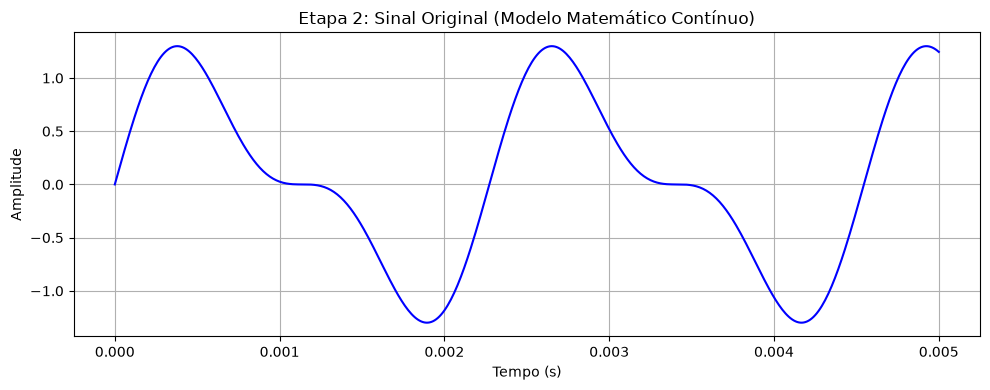

Áudio do sinal original:


In [19]:
# Parâmetros do modelo
A1 = 1.0; f1 = 440.0
A2 = 0.5; f2 = 880.0

# Simulação do sinal "contínuo" (resolução muito alta)
fs_cont = 100000  # 100 kHz para simular contínuo
t_cont = np.arange(0, 2.0, 1/fs_cont) # 2 segundos de áudio
x_cont = A1 * np.sin(2 * np.pi * f1 * t_cont) + A2 * np.sin(2 * np.pi * f2 * t_cont)

# Plotando um pequeno trecho (0 a 0.005 s) para visualização
t_plot = t_cont[t_cont <= 0.005]
x_plot = x_cont[t_cont <= 0.005]

plt.figure(figsize=(10, 4))
plt.plot(t_plot, x_plot, 'b-')
plt.title('Etapa 2: Sinal Original (Modelo Matemático Contínuo)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('figuras/01_sinal_continuo.png')
plt.show()

# Opcional: Ouvir o sinal contínuo gerado
print("Áudio do sinal original:")
ipd.display(ipd.Audio(data=x_cont, rate=fs_cont))


## Etapa 3: Amostragem
Para digitalizar o sinal, vamos amostrá-lo com uma frequência $f_s$. Como a frequência máxima do nosso sinal é 880 Hz, pelo Teorema de Nyquist, $f_s$ deve ser maior que 1760 Hz. Escolheremos $f_s = 8000$ Hz (padrão para voz/telefone).

O intervalo de amostragem será $T_s = 1 / f_s$ e o sinal discreto será $x[n] = x(n T_s)$.

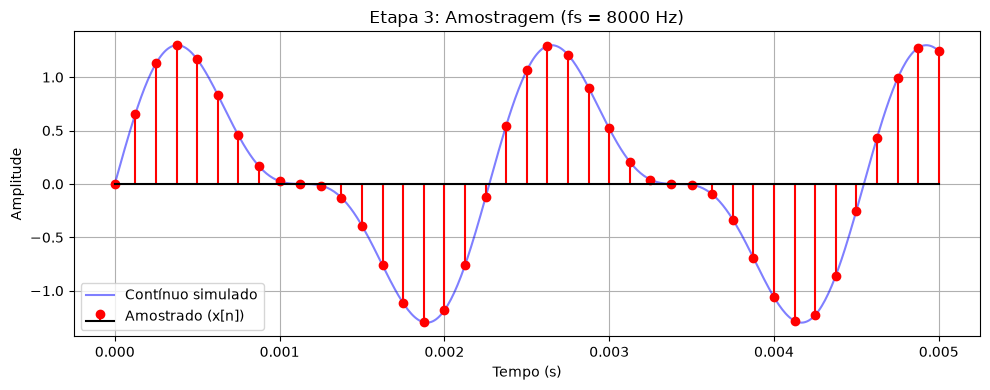

In [20]:
fs = 8000
Ts = 1.0 / fs
n = np.arange(0, int(2.0 * fs)) # Índices discretos para 2 segundos
t_disc = n * Ts
x_disc = A1 * np.sin(2 * np.pi * f1 * t_disc) + A2 * np.sin(2 * np.pi * f2 * t_disc)

# Plotando comparação num trecho curto
n_plot = n[t_disc <= 0.005]
t_disc_plot = t_disc[t_disc <= 0.005]
x_disc_plot = x_disc[t_disc <= 0.005]

plt.figure(figsize=(10, 4))
plt.plot(t_plot, x_plot, 'b-', alpha=0.5, label='Contínuo simulado')
plt.stem(t_disc_plot, x_disc_plot, linefmt='r-', markerfmt='ro', basefmt='k-', label='Amostrado (x[n])')
plt.title(f'Etapa 3: Amostragem (fs = {fs} Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figuras/02_amostragem.png')
plt.show()


## Etapa 4: Quantização
Vamos simular a quantização assumindo que o conversor A/D opera no intervalo [-1.5, 1.5] (já que o sinal máximo é 1.5). Testaremos duas resoluções: $N_1 = 4$ bits (16 níveis) e $N_2 = 8$ bits (256 níveis).

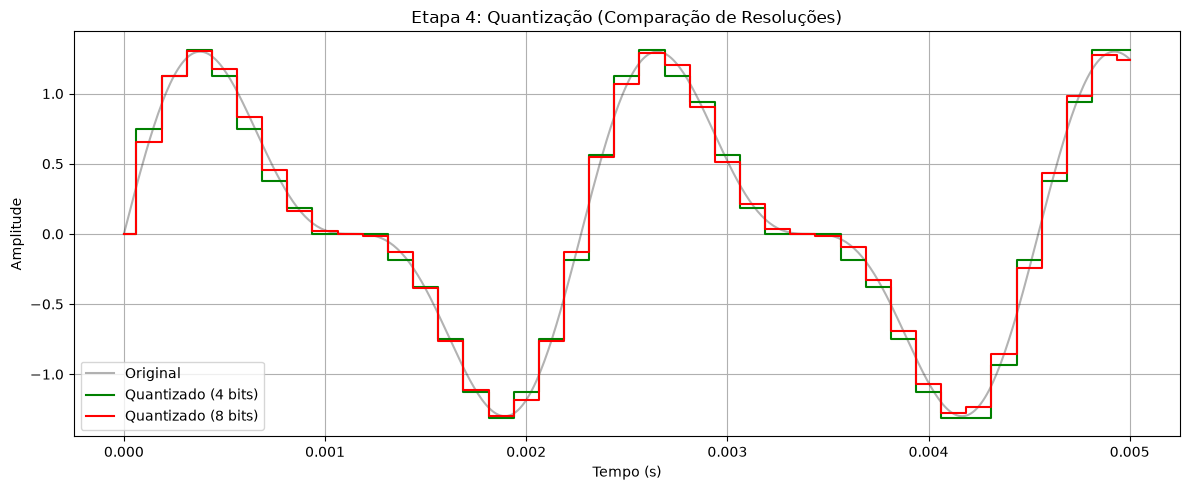

In [21]:
def quantizar(sinal, bits, vmin=-1.5, vmax=1.5):
    n_niveis = 2**bits
    delta = (vmax - vmin) / n_niveis
    # Normaliza e arredonda
    sinal_q = np.round((np.clip(sinal, vmin, vmax) - vmin) / delta) * delta + vmin
    return sinal_q

x_q4 = quantizar(x_disc, 4)
x_q8 = quantizar(x_disc, 8)

plt.figure(figsize=(12, 5))
plt.plot(t_plot, x_plot, 'k-', alpha=0.3, label='Original')
plt.step(t_disc_plot, x_q4[0:len(t_disc_plot)], 'g', where='mid', label='Quantizado (4 bits)')
plt.step(t_disc_plot, x_q8[0:len(t_disc_plot)], 'r', where='mid', label='Quantizado (8 bits)')
plt.title('Etapa 4: Quantização (Comparação de Resoluções)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figuras/03_quantizacao.png')
plt.show()


## Etapa 5: Inclusão de Ruído
Vamos adicionar um ruído Gaussiano branco ao nosso sinal quantizado (usaremos o de 8 bits para as próximas etapas). 
$x_r[n] = x_{q8}[n] + r[n]$
A amplitude do ruído será escolhida para corromper visivelmente e audivelmente o sinal (desvio padrão $\sigma = 0.3$).

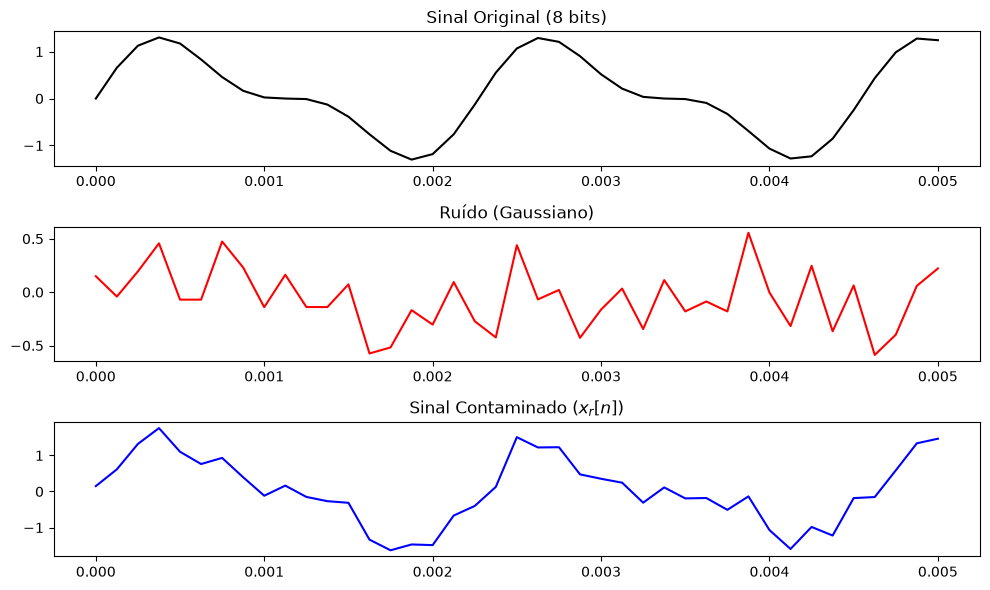

Áudio Contaminado com Ruído:


In [22]:
np.random.seed(42) # Para reprodutibilidade
ruido = np.random.normal(0, 0.3, len(x_q8))
xr = x_q8 + ruido

# Plot
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t_disc_plot, x_q8[:len(t_disc_plot)], 'k')
plt.title('Sinal Original (8 bits)')

plt.subplot(3, 1, 2)
plt.plot(t_disc_plot, ruido[:len(t_disc_plot)], 'r')
plt.title('Ruído (Gaussiano)')

plt.subplot(3, 1, 3)
plt.plot(t_disc_plot, xr[:len(t_disc_plot)], 'b')
plt.title('Sinal Contaminado ($x_r[n]$)')

plt.tight_layout()
plt.savefig('figuras/04_inclusao_ruido.png')
plt.show()

print("Áudio Contaminado com Ruído:")
ipd.display(ipd.Audio(data=xr, rate=fs))


## Etapa 6 e 7: Processamento por Sistema LTI e Comparação
Aplicaremos um **filtro de média móvel** (que atua como passa-baixas e é um sistema LTI) para tentar reduzir o ruído de alta frequência.
$h[n] = \frac{1}{M} \{1, 1, \dots, 1\}$
Escolheremos $M=7$. O motivo: Como o sinal fundamental está em 440 Hz e 880 Hz, e nossa $f_s$ é 8000 Hz, um $M=7$ causará o primeiro nulo de frequência em torno de $8000/7 \approx 1142$ Hz. Isso preserva as notas musicais, atenuando ruídos mais agudos. M muito grande (ex: 50) distorceria muito os harmônicos.

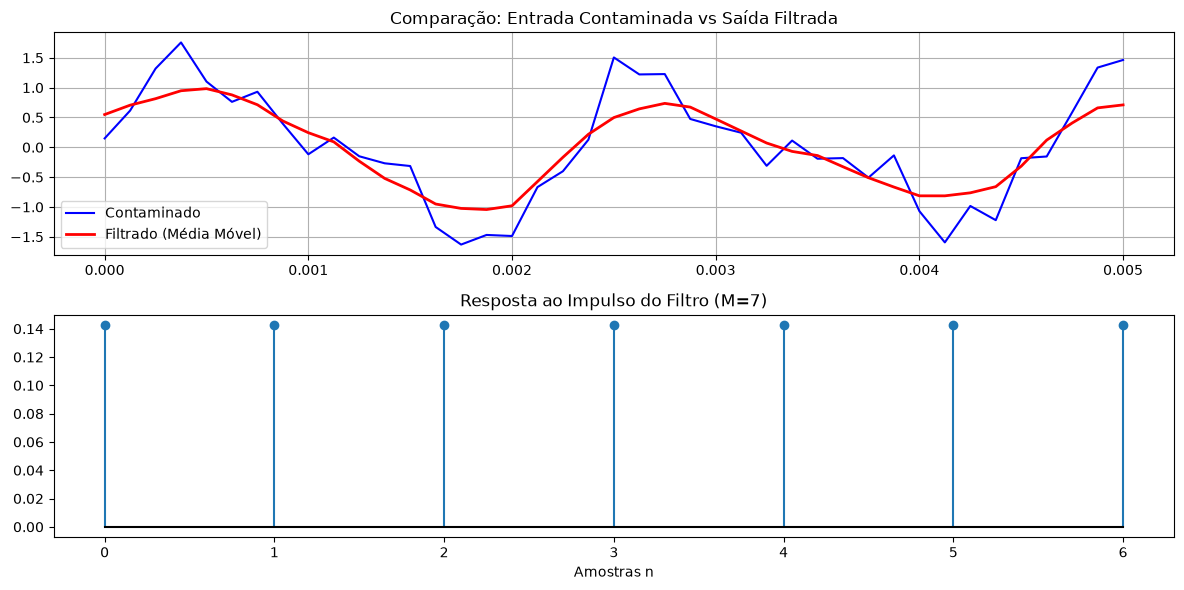

Áudio Filtrado (Sistema LTI):


In [23]:
M = 7
h = np.ones(M) / M

# Processamento: Convolução de xr com h
y_filtrado = np.convolve(xr, h, mode='same')

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t_disc_plot, xr[:len(t_disc_plot)], 'b', label='Contaminado')
plt.plot(t_disc_plot, y_filtrado[:len(t_disc_plot)], 'r', linewidth=2, label='Filtrado (Média Móvel)')
plt.title('Comparação: Entrada Contaminada vs Saída Filtrada')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(np.arange(M), h, basefmt='k-')
plt.title(f'Resposta ao Impulso do Filtro (M={M})')
plt.xlabel('Amostras n')
plt.tight_layout()
plt.savefig('figuras/05_filtragem_lti.png')
plt.show()

print("Áudio Filtrado (Sistema LTI):")
ipd.display(ipd.Audio(data=y_filtrado, rate=fs))


## Etapa 8: Discussão

**Respostas às questões do roteiro:**
1. **Como o fenômeno foi representado matematicamente?** Foi modelado como a soma de duas sinusoides ($440$ Hz e $880$ Hz) representando uma nota musical e seu harmônico.
2. **Como a escolha de $f_s$ modificou a representação do sinal?** Com $f_s = 8000$ Hz, convertemos o tempo contínuo $t$ para instantes discretos $n/f_s$. O sinal tornou-se uma sequência de amostras sem perder informação, pois $8000 > 2 \times 880$ (Nyquist).
3. **Qual foi o efeito da quantização?** A quantização arredondou as amplitudes contínuas para valores fixos (degraus).
4. **Como o número de bits afetou o resultado?** Com 4 bits, os degraus ficaram muito grandes, gerando ruído de quantização visual (e audível). Com 8 bits, o sinal ficou visualmente idêntico ao original, com maior fidelidade.
5. **Qual foi o efeito do ruído?** O ruído gaussiano adicionou variações aleatórias, "borrando" o sinal e introduzindo um chiado agudo ao escutar o áudio.
6. **Qual a resposta ao impulso do sistema utilizado?** $h[n] = [1/7, 1/7, 1/7, 1/7, 1/7, 1/7, 1/7]$ (um pulso retangular de 7 amostras).
7. **Por que o sistema utilizado pode ser considerado LTI?** É Linear pois atende à superposição e homogeneidade (a média de uma soma é a soma das médias) e Invariante no Tempo pois atrasar a entrada apenas atrasa a saída na mesma proporção.
8. **Qual foi o efeito da convolução?** A convolução calculou a média de 7 amostras vizinhas para cada ponto, suavizando as flutuações rápidas.
9. **O sistema reduziu as variações introduzidas pelo ruído?** Sim, atenuou as variações bruscas (altas frequências) do ruído.
10. **Houve alteração significativa do sinal de interesse?** O sinal base sofreu leve atenuação em seu pico e uma defasagem. Porém, como $M=7$ foi cuidadosamente escolhido para não afetar 440/880Hz agressivamente, a nota permaneceu inteligível.
11. **Quais limitações foram observadas?** O filtro de média móvel atenua todas as frequências altas. Se o ruído compartilhar as mesmas baixas frequências do sinal, ele não consegue eliminá-lo.
12. **Como o modelo poderia ser melhorado?** Aplicando filtros digitais mais seletivos (como Butterworth ou Chebyshev) desenhados no domínio da frequência para atuar apenas nas bandas ruidosas, ou usar técnicas de subtração espectral (redução não-linear de ruído).
